In [4]:
from qutip import *
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib
import sys
from pathlib import Path
import json
from lmfit import Model
from matplotlib.ticker import MaxNLocator


import scienceplots as splt
matplotlib.pyplot.style.use(['science', 'notebook', 'ieee'])
matplotlib.pyplot.rcParams['font.family'] = 'Times New Roman'


# Aggiunge src alla path dei moduli
project_root = Path.cwd().parent.parent 
sys.path.append(str(project_root / "src"))


from molecules.molecule import CaH, CaOH, CaOH_dm2, CaH_dm2

from pumping.pump_evolution import run_pumping


# Cutting Dataframe approach

Due to high computational effort, with $J>8$ the molecular dataframe is properly cut to consider a fewer amount of states, in order to investigate the amount of population in the leftmost states. The remaining states are 10, and they correspond to the 5 leftmost states in the upper sub manifold, and the 5 leftmost states in the lower sub-manifold. 

# Molecule and pulse creation

In [5]:
b_field_gauss = 3.6
j_max = 15

temperature = 300

molecule_type = "CaH"

n_motional = 4

e_ops = []

final_time = 1000*10   # us           
dt = 5
times_1 = np.arange(0,final_time+dt,dt)

final_time = 1000*15   
times_2 = np.arange(0,final_time+dt,dt)

final_time = 1000*20   
times_3 = np.arange(0,final_time+dt,dt)

detuning_1 = 2 * np.pi * -0.002
detuning_2 = 2 * np.pi * -0.006
rabi_rate = 2 * np.pi * 0.01
is_minus = True


laser_configs = [

    {
        "name": "pulse_1",
        "is_minus": is_minus,
        "times": times_1,  
        "laser_detuning": detuning_1,
        "rabi_rate": rabi_rate,
        "raman_config": "dm1"
    },

    {
        "name": "pulse_2",
        "is_minus": is_minus,
        "times": times_1,
        "laser_detuning": detuning_2,
        "rabi_rate": rabi_rate,
        "raman_config": "dm1"
    },

    {
        "name": "pulse_3",
        "is_minus": is_minus,
        "times": times_2,
        "laser_detuning": detuning_1*2,
        "rabi_rate": rabi_rate,
        "raman_config": "dm2"
    },

    {
        "name": "pulse_4",
        "is_minus": is_minus,
        "times": times_2,
        "laser_detuning": detuning_2*2,
        "rabi_rate": rabi_rate,
        "raman_config": "dm2"
    },

    {
        "name": "pulse_5",
        "is_minus": is_minus,
        "times": times_3,
        "laser_detuning": detuning_1,
        "rabi_rate": rabi_rate,
        "raman_config": "dm1"
    },

    {
        "name": "pulse_6",
        "is_minus": is_minus,
        "times": times_3,
        "laser_detuning": detuning_2,
        "rabi_rate": rabi_rate,
        "raman_config": "dm1"
    }
]


# J=9

Saved molecule data in:
/home/stripzio/bayesian-qls/re_project/molecule_data/CaH_B[3.60]_Jmax[15]_states.csv
/home/stripzio/bayesian-qls/re_project/molecule_data/CaH_B[3.60]_Jmax[15]_transitions.csv
Saved molecule data in:
/home/stripzio/bayesian-qls/re_project/molecule_data/CaH_B[3.60]_Jmax[15]_states.csv
/home/stripzio/bayesian-qls/re_project/molecule_data/CaH_B[3.60]_Jmax[15]_transitions.csv


/home/stripzio/bayesian-qls/re_project/src/pumping/pump_utils.py:98: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["index1"] = df_filtered["index1"].apply(lambda x: x - delta if x >= m_len else x)
/home/stripzio/bayesian-qls/re_project/src/pumping/pump_utils.py:99: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["index2"] = df_filtered["index2"].apply(lambda x: x - delta if x >= m_len else x)
/home/stripzio/bayesian-qls/re_project/src/pumping/pump_utils.py:102: SettingWithCopyWarning: 

10.0%. Run time:   7.51s. Est. time left: 00:00:01:07
20.0%. Run time:  12.31s. Est. time left: 00:00:00:49
30.0%. Run time:  16.61s. Est. time left: 00:00:00:38
40.0%. Run time:  20.72s. Est. time left: 00:00:00:31
50.0%. Run time:  24.85s. Est. time left: 00:00:00:24
60.0%. Run time:  29.07s. Est. time left: 00:00:00:19
70.0%. Run time:  33.32s. Est. time left: 00:00:00:14
80.0%. Run time:  37.52s. Est. time left: 00:00:00:09
90.0%. Run time:  44.76s. Est. time left: 00:00:00:04
100.0%. Run time:  49.19s. Est. time left: 00:00:00:00
Total run time:  49.19s
Final state saved in: /home/stripzio/bayesian-qls/re_project/results_pumping_cah/J9_B3.60G_T10.0ms_RR10.0000_DET-2.0000_CR10.0000_0.pkl
10.0%. Run time:   4.64s. Est. time left: 00:00:00:41
20.0%. Run time:   9.20s. Est. time left: 00:00:00:36
30.0%. Run time:  13.50s. Est. time left: 00:00:00:31
40.0%. Run time:  17.78s. Est. time left: 00:00:00:26
50.0%. Run time:  21.91s. Est. time left: 00:00:00:21
60.0%. Run time:  29.01s. Est

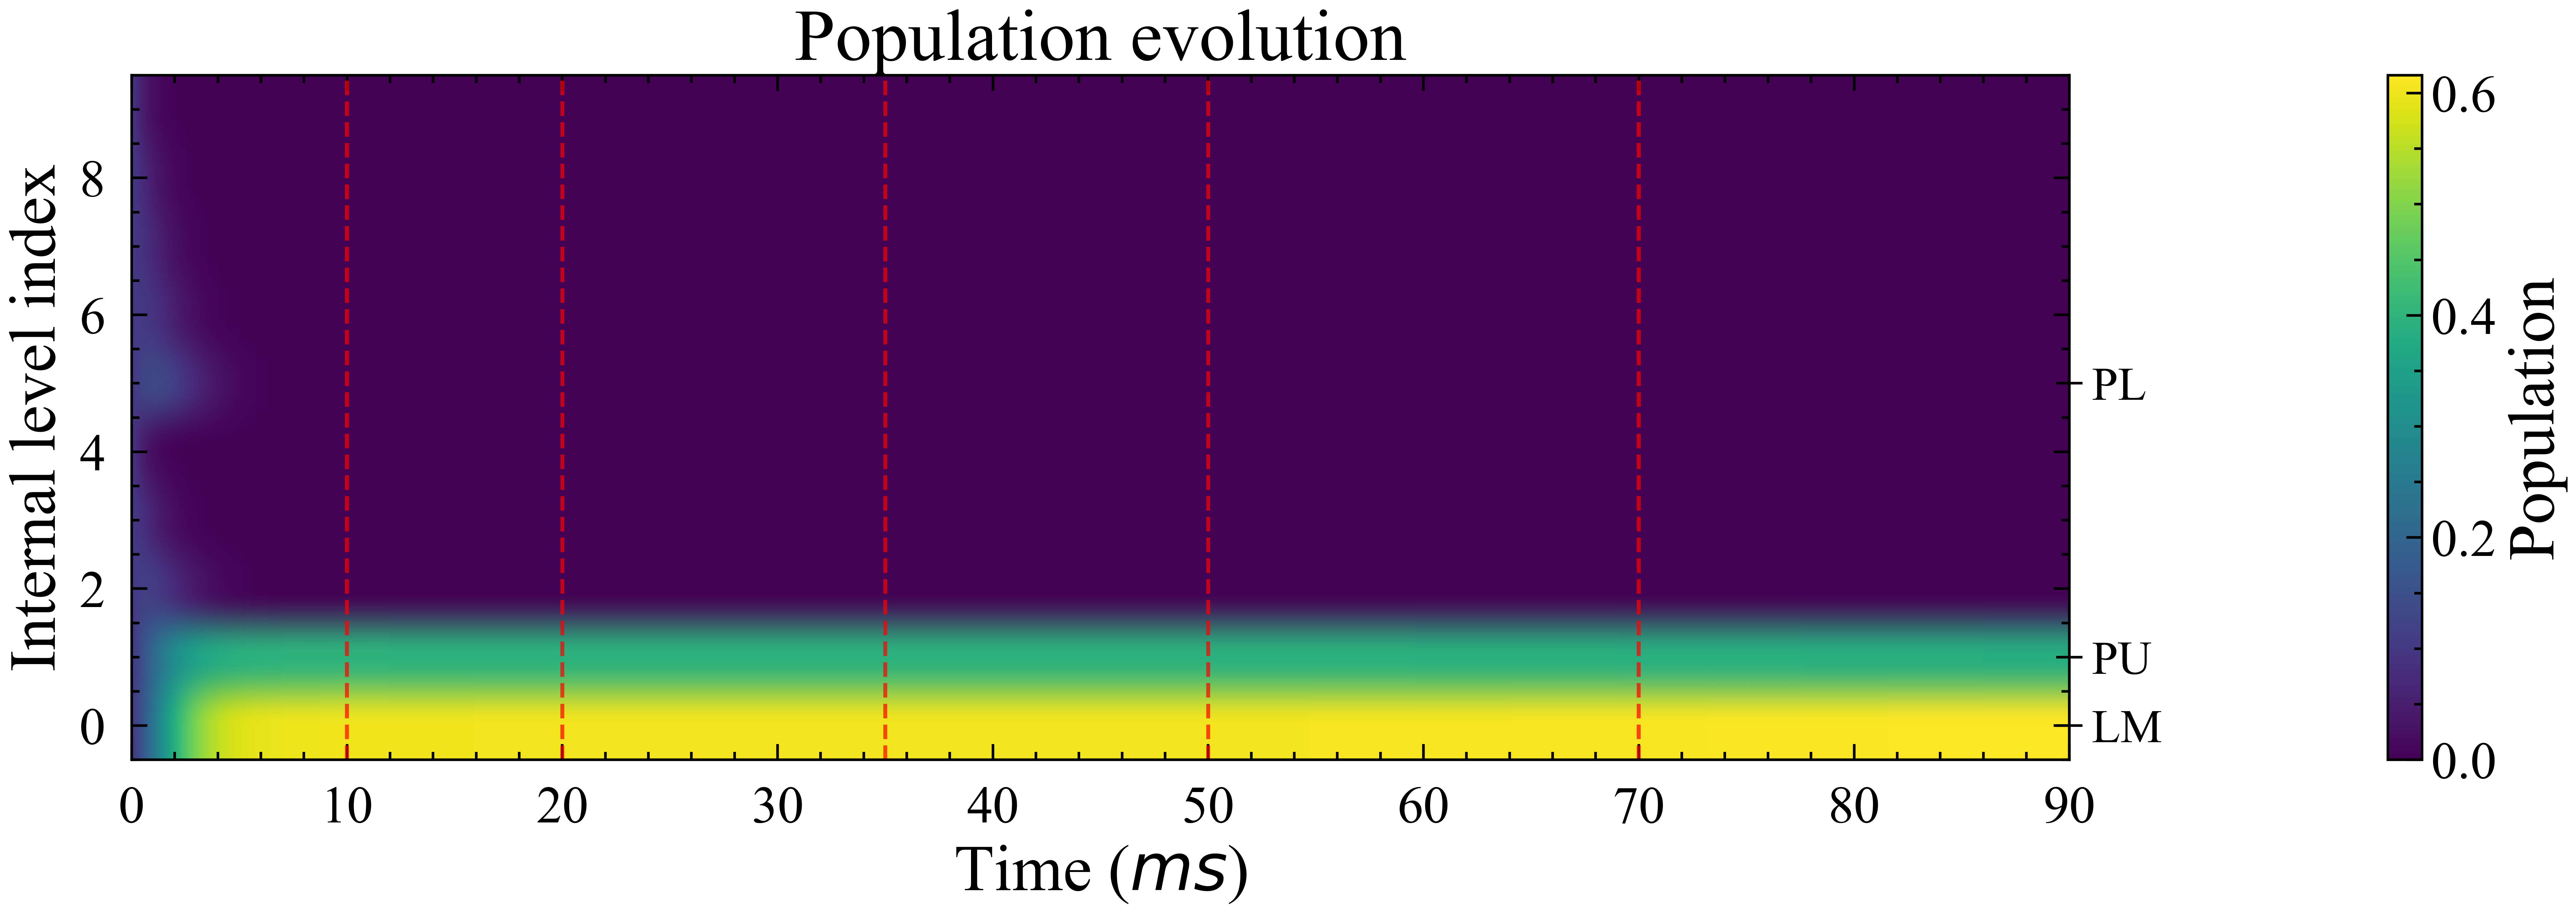

In [6]:
j_val = 9

run_pumping (b_field_gauss, j_max, temperature, j_val, n_motional, 
             laser_configs, e_ops,
             molecule_type = molecule_type,
             save_intermediate_states=True, plot_intermediate_dynamics=False)

# J=11

Saved molecule data in:
/home/stripzio/bayesian-qls/re_project/molecule_data/CaH_B[3.60]_Jmax[15]_states.csv
/home/stripzio/bayesian-qls/re_project/molecule_data/CaH_B[3.60]_Jmax[15]_transitions.csv
Saved molecule data in:
/home/stripzio/bayesian-qls/re_project/molecule_data/CaH_B[3.60]_Jmax[15]_states.csv
/home/stripzio/bayesian-qls/re_project/molecule_data/CaH_B[3.60]_Jmax[15]_transitions.csv


/home/stripzio/bayesian-qls/re_project/src/pumping/pump_utils.py:98: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["index1"] = df_filtered["index1"].apply(lambda x: x - delta if x >= m_len else x)
/home/stripzio/bayesian-qls/re_project/src/pumping/pump_utils.py:99: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["index2"] = df_filtered["index2"].apply(lambda x: x - delta if x >= m_len else x)
/home/stripzio/bayesian-qls/re_project/src/pumping/pump_utils.py:102: SettingWithCopyWarning: 

10.0%. Run time:   4.83s. Est. time left: 00:00:00:43
20.0%. Run time:   9.48s. Est. time left: 00:00:00:37
30.0%. Run time:  14.18s. Est. time left: 00:00:00:33
40.0%. Run time:  18.95s. Est. time left: 00:00:00:28
50.0%. Run time:  26.88s. Est. time left: 00:00:00:26
60.0%. Run time:  31.63s. Est. time left: 00:00:00:21
70.0%. Run time:  36.37s. Est. time left: 00:00:00:15
80.0%. Run time:  41.90s. Est. time left: 00:00:00:10
90.0%. Run time:  47.20s. Est. time left: 00:00:00:05
100.0%. Run time:  52.55s. Est. time left: 00:00:00:00
Total run time:  52.55s
Final state saved in: /home/stripzio/bayesian-qls/re_project/results_pumping_cah/J11_B3.60G_T10.0ms_RR10.0000_DET-2.0000_CR10.0000_0.pkl
10.0%. Run time:  11.26s. Est. time left: 00:00:01:41
20.0%. Run time:  19.43s. Est. time left: 00:00:01:17
30.0%. Run time:  28.04s. Est. time left: 00:00:01:05
40.0%. Run time:  36.51s. Est. time left: 00:00:00:54
50.0%. Run time:  48.48s. Est. time left: 00:00:00:48
60.0%. Run time:  56.85s. Es

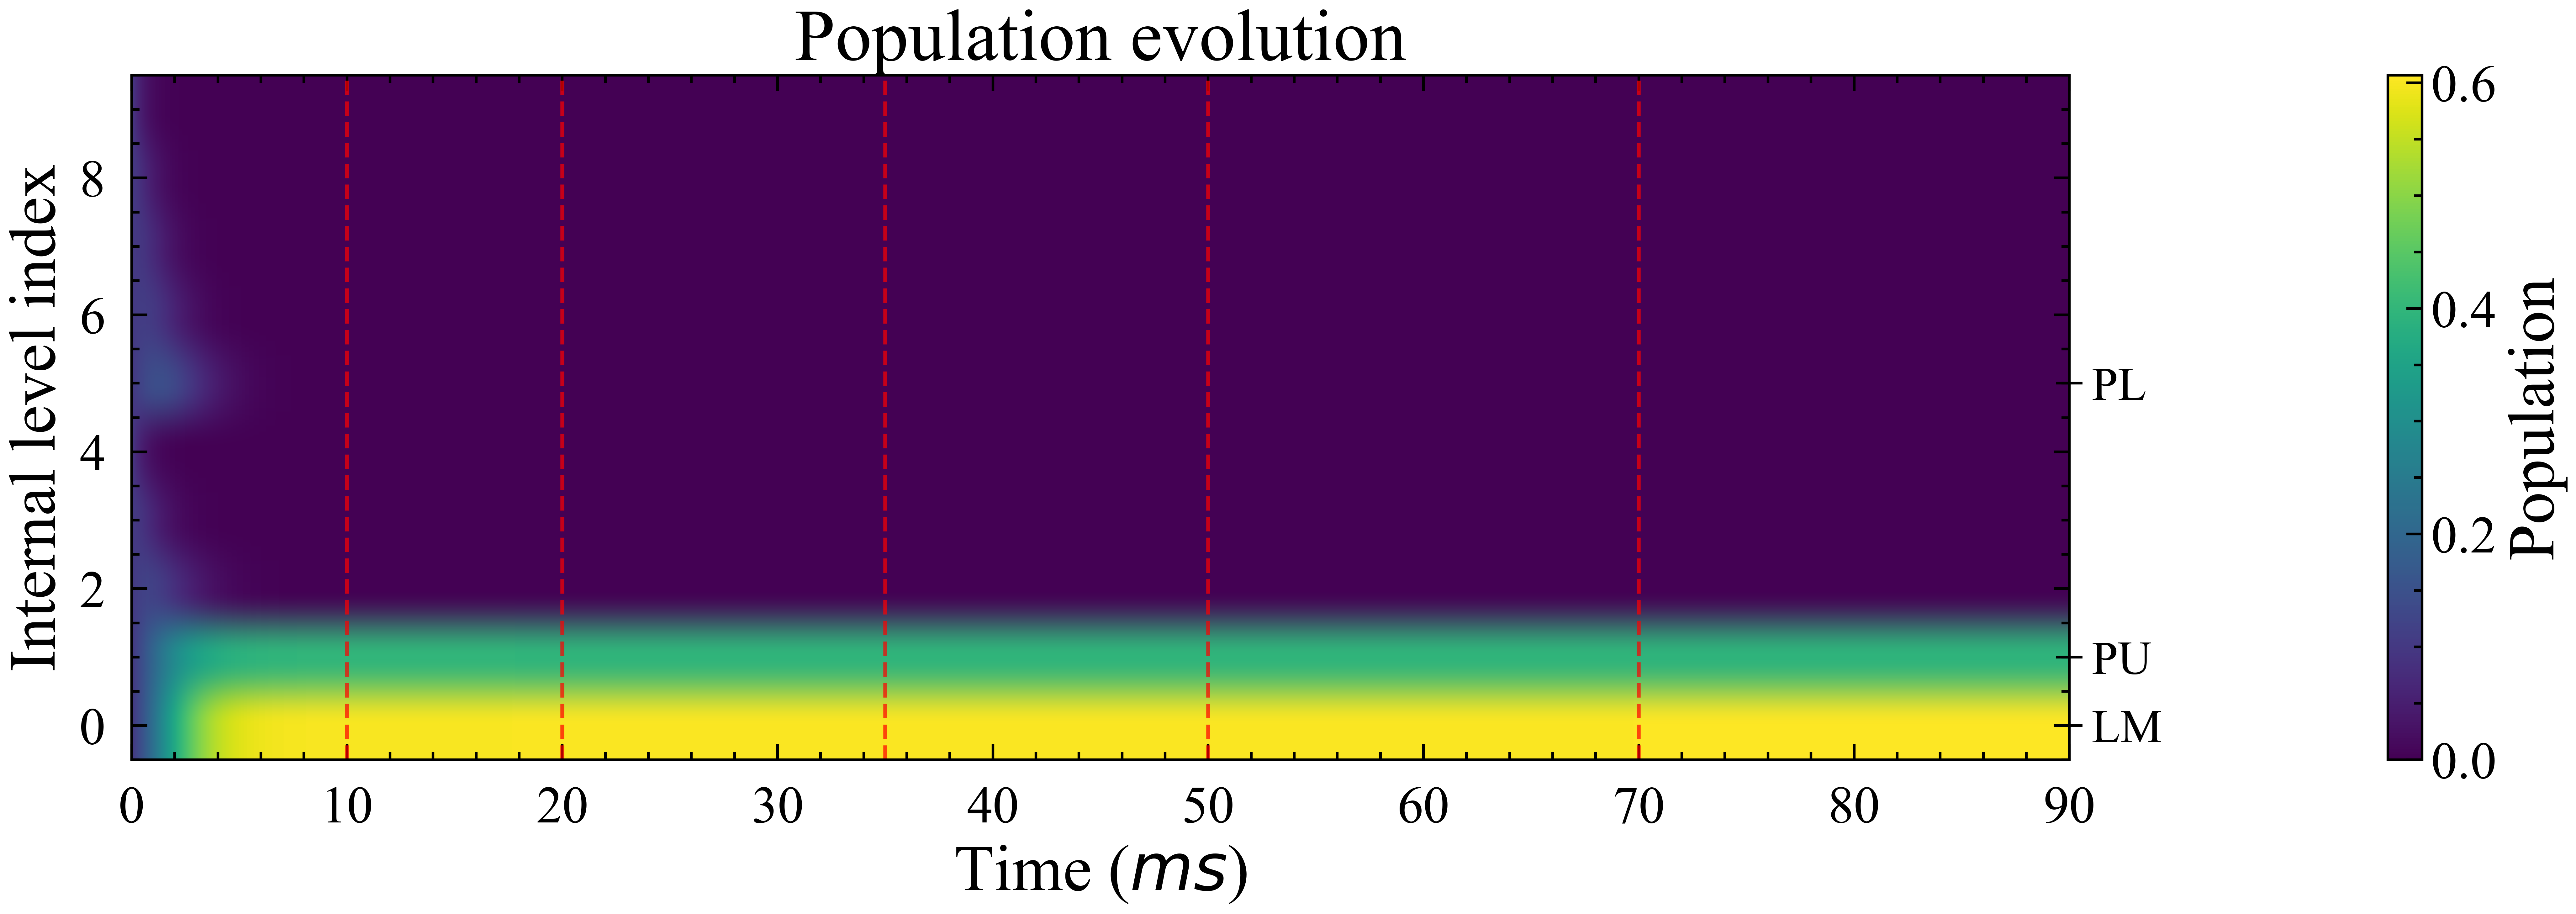

In [7]:
j_val = 11

run_pumping (b_field_gauss, j_max, temperature, j_val, n_motional, 
             laser_configs, e_ops,
             molecule_type = molecule_type,
             save_intermediate_states=True, plot_intermediate_dynamics=False)

# J=13

Saved molecule data in:
/home/stripzio/bayesian-qls/re_project/molecule_data/CaH_B[3.60]_Jmax[15]_states.csv
/home/stripzio/bayesian-qls/re_project/molecule_data/CaH_B[3.60]_Jmax[15]_transitions.csv
Saved molecule data in:
/home/stripzio/bayesian-qls/re_project/molecule_data/CaH_B[3.60]_Jmax[15]_states.csv
/home/stripzio/bayesian-qls/re_project/molecule_data/CaH_B[3.60]_Jmax[15]_transitions.csv


/home/stripzio/bayesian-qls/re_project/src/pumping/pump_utils.py:98: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["index1"] = df_filtered["index1"].apply(lambda x: x - delta if x >= m_len else x)
/home/stripzio/bayesian-qls/re_project/src/pumping/pump_utils.py:99: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["index2"] = df_filtered["index2"].apply(lambda x: x - delta if x >= m_len else x)
/home/stripzio/bayesian-qls/re_project/src/pumping/pump_utils.py:102: SettingWithCopyWarning: 

10.0%. Run time:   6.02s. Est. time left: 00:00:00:54
20.0%. Run time:  11.06s. Est. time left: 00:00:00:44
30.0%. Run time:  18.79s. Est. time left: 00:00:00:43
40.0%. Run time:  23.62s. Est. time left: 00:00:00:35
50.0%. Run time:  28.48s. Est. time left: 00:00:00:28
60.0%. Run time:  33.66s. Est. time left: 00:00:00:22
70.0%. Run time:  38.40s. Est. time left: 00:00:00:16
80.0%. Run time:  43.40s. Est. time left: 00:00:00:10
90.0%. Run time:  51.39s. Est. time left: 00:00:00:05
100.0%. Run time:  56.55s. Est. time left: 00:00:00:00
Total run time:  56.55s
Final state saved in: /home/stripzio/bayesian-qls/re_project/results_pumping_cah/J13_B3.60G_T10.0ms_RR10.0000_DET-2.0000_CR10.0000_0.pkl
10.0%. Run time:   5.48s. Est. time left: 00:00:00:49
20.0%. Run time:  11.25s. Est. time left: 00:00:00:45
30.0%. Run time:  20.48s. Est. time left: 00:00:00:47
40.0%. Run time:  33.29s. Est. time left: 00:00:00:49
50.0%. Run time:  40.35s. Est. time left: 00:00:00:40
60.0%. Run time:  45.70s. Es

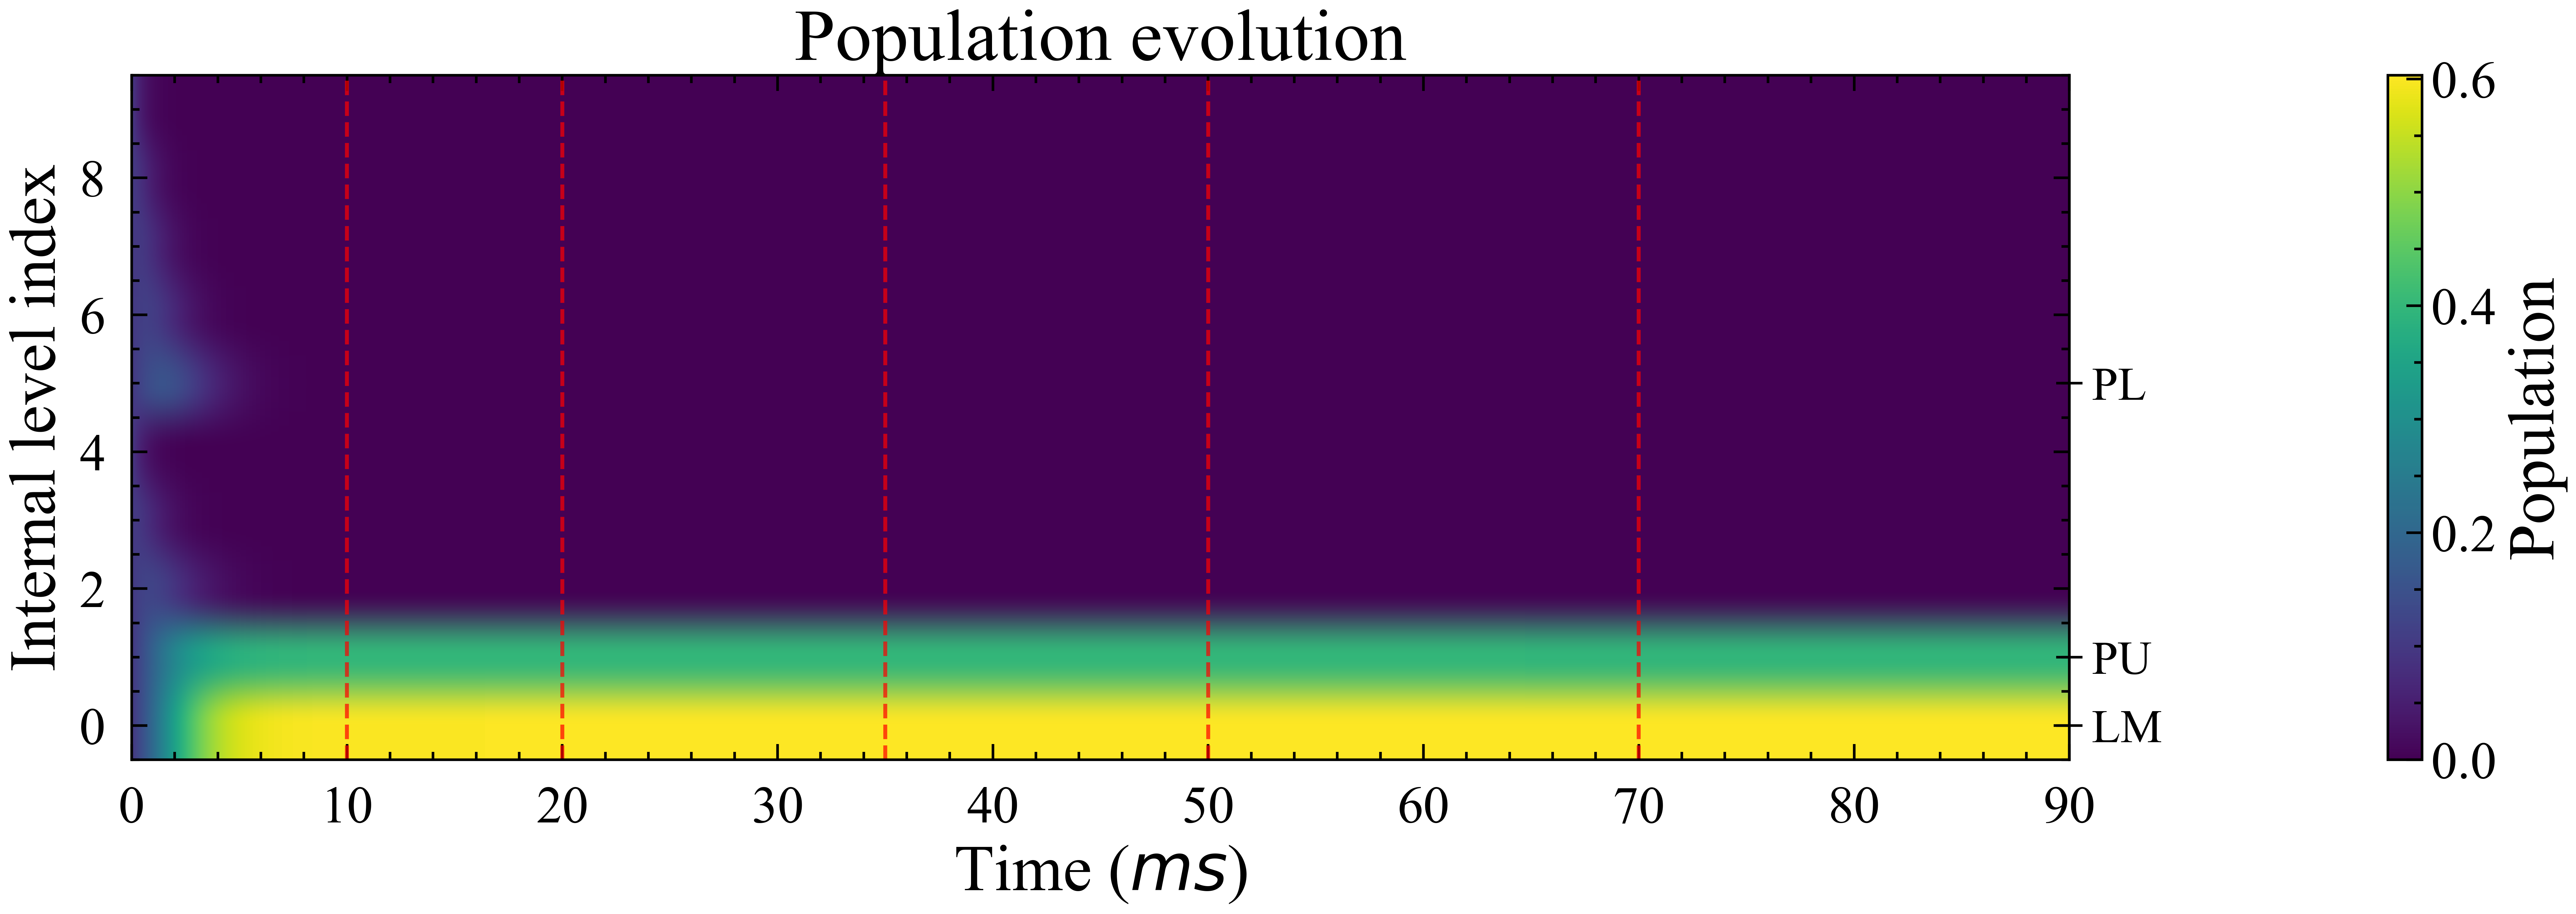

In [8]:
j_val = 13

run_pumping (b_field_gauss, j_max, temperature, j_val, n_motional, 
             laser_configs, e_ops,
             molecule_type = molecule_type,
             save_intermediate_states=True, plot_intermediate_dynamics=False)